# Block 2 — Deep Learning with Time Series Data: Recurrent Neural Networks

**Goals for this block:**
- Build and train RNN model using Tensorflow
- Introduction to the Darts Library for time series forecasting
- Implement preprocessing steps from Block 1 using Darts
- Build and train RNN model using Tensorflow using Darts


## 0. Setup & Environment


In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6500)])

import torch
assert torch.cuda.is_available()
torch.cuda.set_per_process_memory_fraction(0.3)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

## 1. Data Loading & Preparation

We'll work with an **energy generation** dataset from Block 1. This synthetic dataset contains energy consumption patterns that exhibit both temporal dependencies and seasonality, making it ideal for time series forecasting tasks.

In [3]:
# GUIDE: load and preprocess data

df = pd.read_csv("energy_synthetic.csv")
# Try to parse a timestamp column smartly
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df['timestamp'] = df['timestamp'].dt.tz_localize(None)
df = df.set_index('timestamp').sort_index()

## 2. Training Recurrent Neural Networks with TensorFlow

In this section, we'll implement a Recurrent Neural Network (RNN) model using TensorFlow to forecast our time series data.

### 2.1 Data Preprocessing

First, let's encapsulate all preprocessing steps from Block 1 into a single function to streamline our workflow.

In [4]:
def preprocessing_data(df, resample_freq='D', agg_method='mean', 
                      train_ratio=0.7, val_ratio=0.15, 
                      scaling_method='zscore', 
                      window_size=24, forecast_horizon=1, stride=1):
    """
    Complete time series preprocessing pipeline.
    Returns:
    - Dictionary with X_train, y_train, X_val, y_val, X_test, y_test, scaler
    """
    
    # 1. Handle missing values
    filled = df.interpolate(method='linear')
    
    # 2. Resample data
    if agg_method == 'mean':
        resampled = filled.resample(resample_freq).mean()
    elif agg_method == 'sum':
        resampled = filled.resample(resample_freq).sum()
    elif agg_method == 'last':
        resampled = filled.resample(resample_freq).last()
    else:
        raise ValueError('Unsupported aggregation method')
    
    # 3. Time-aware split
    n = len(resampled)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    
    train = resampled.iloc[:n_train]
    val = resampled.iloc[n_train:n_train+n_val]
    test = resampled.iloc[n_train+n_val:]
    
    # 4. Scaling (fit only on training data)
    if scaling_method == 'standard':
        scaler = StandardScaler()
    elif scaling_method == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_method == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError('Unsupported scaling method')
    
    scaler.fit(train.values)
    
    train_scaled = pd.DataFrame(scaler.transform(train.values), 
                               index=train.index, columns=train.columns)
    val_scaled = pd.DataFrame(scaler.transform(val.values), 
                             index=val.index, columns=val.columns)
    test_scaled = pd.DataFrame(scaler.transform(test.values), 
                              index=test.index, columns=test.columns)
    
    # 5. Create sliding windows
    def make_windows(series, window_size, forecast_horizon, stride):
        Xs, ys = [], []
        
        for i in range(0, len(series) - window_size - forecast_horizon + 1, stride):
            X_window = series[i:i + window_size]
            y_window = series[i + window_size:i + window_size + forecast_horizon]
            Xs.append(X_window)
            ys.append(y_window)
        
        return np.array(Xs), np.array(ys)
    
    X_train, y_train = make_windows(train_scaled, window_size, forecast_horizon, stride)
    X_val, y_val = make_windows(val_scaled, window_size, forecast_horizon, stride)
    X_test, y_test = make_windows(test_scaled, window_size, forecast_horizon, stride)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

In [5]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = preprocessing_data(df,
                                                                            resample_freq='h',
                                                                            agg_method='mean',
                                                                            scaling_method='standard',
                                                                            train_ratio=0.7,
                                                                            val_ratio=0.15,
                                                                            window_size=24,
                                                                            forecast_horizon=1,
                                                                            stride=1)


In [6]:
# print shapes
print(f"X_train: (num_samples, window_size, num_features) -> {X_train.shape}\ny_train: (num_samples, forecast_horizon, num_features) -> {y_train.shape} ")

X_train: (num_samples, window_size, num_features) -> (12240, 24, 1)
y_train: (num_samples, forecast_horizon, num_features) -> (12240, 1, 1) 


In [7]:
print("Shapes:", X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)


Shapes: (12240, 24, 1) (12240, 1, 1) (2604, 24, 1) (2604, 1, 1) (2604, 24, 1) (2604, 1, 1)


### 2.2 Building the TensorFlow RNN Model

Now we'll create and train a simple RNN model using TensorFlow's Keras API.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

#### Model Architecture:
- Simple RNN with two stacked layers (50 units each)
- First RNN layer returns sequences to connect with the second layer (`return_sequences=True`)
- Output Dense layer with `forecast_horizon` units to generate predictions
- Adam optimizer with Mean Squared Error loss function

In [9]:
model_tf = Sequential()
model_tf.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_tf.add(SimpleRNN(units=50, return_sequences=False))
model_tf.add(Dense(units=y_train.shape[2]))
model_tf.compile(optimizer='adam', loss='mean_squared_error')

2025-11-09 16:29:44.479909: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-11-09 16:29:44.479967: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-11-09 16:29:44.479978: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2025-11-09 16:29:44.480006: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-09 16:29:44.480027: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

**What’s happening**:

`SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))`

- SimpleRNN: a vanilla recurrent layer.
- units=50: the hidden_dim — 50 neurons → each time step’s hidden state has 50 features.
- input_shape=(timesteps, features): this tells Keras the shape of your input sequence:
- X_train_ex.shape[1] = number of time steps in each training sample
- X_train_ex.shape[2] = number of features per step
- return_sequences=True: means this layer will output the full sequence of hidden states, not just the last one.
    **Why?**
    Because you’re stacking another RNN layer next — it needs the entire sequence (not a single vector).

`Dense(units=y_train.shape[2])`
- A fully connected layer mapping from the RNN’s output vector → the desired target shape.
- units=y_train_ex.shape[2]: If you’re predicting a multivariate time series, this equals the number of output features per time step (e.g., 1 for univariate forecasting, >1 for multivariate).

### 2.3 Model Training

Let's train our TensorFlow RNN model with the preprocessed data.

In [10]:
history = model_tf.fit(
    X_train, 
    y_train, 
    epochs=2, 
    batch_size=256, 
    validation_data=(X_val, y_val), 
    verbose=1)


Epoch 1/2


2025-11-09 16:29:45.023099: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - loss: 0.1584 - val_loss: 0.1227
Epoch 2/2
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 348ms/step - loss: 0.1013 - val_loss: 0.1243


### 2.4 Making Predictions

Now we'll use our trained model to generate predictions on the test dataset.

In [11]:
y_pred = model_tf.predict(X_test)

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


### 2.5 Model Evaluation

Let's evaluate our TensorFlow RNN model using appropriate metrics and visualization.

Unscaled Mean Squared Error (MSE): 6.202236791772237


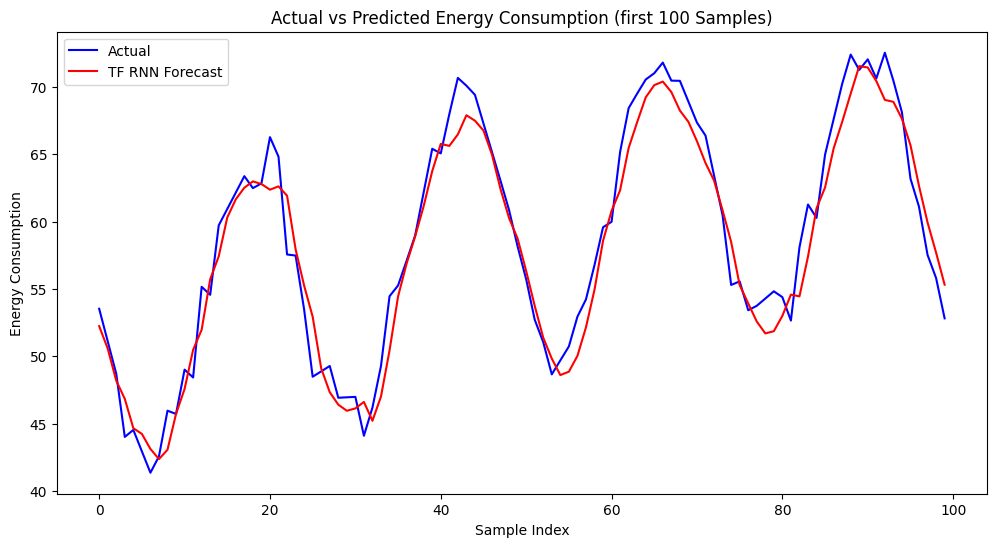

In [ ]:
from sklearn.metrics import mean_absolute_error 

# Inverse transform the predictions and actuals
y_pred_reshaped = scaler.inverse_transform(y_pred)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, y_test.shape[2]))

# Calculate MAE
print(f"Unscaled Mean Squared Error (MAE): {mean_absolute_error(y_test_unscaled, y_pred_reshaped)}")

# Plotting some predictions vs actuals
plt.figure(figsize=(12, 6))
plt.plot(y_test_unscaled[:100, -1], label='Actual', color='blue')
plt.plot(y_pred_reshaped[:100, -1], label='TF RNN Forecast', color='red')
plt.title('Actual vs Predicted Energy Consumption (first 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train RNN with TensorFlow</h2>

Apply what you've learned on the `electricity dataset`:
1. preprocess the dataset
2. design your own RNN architecture
3. train a multivariate RNN model on the 100 costumers 
4. train a univariate RNN model on a specific customer (e.g "MT_001")
5. is the mean squarred error of the univariate model better than on the multivariate?

This exercise will help you design an RNN model and understand the training process.

</div>

In [4]:
df_excercise = pd.read_csv("electricity.csv")
df_excercise['timestamp'] = pd.to_datetime(df_excercise['timestamp'], utc=True, errors='coerce')
df_excercise['timestamp'] = df_excercise['timestamp'].dt.tz_localize(None)
df_excercise = df_excercise.set_index('timestamp').sort_index()

# Uncomment the line below to select only the "MT_001" column for the exercise
# df_exercise = df_excercise[["MT_001"]]

In [14]:
# Preprocess the exercise data: think of the best resampling and aggregation method for the electricity data

X_train_ex, y_train_ex, X_val_ex, y_val_ex, X_test_ex, y_test_ex, scaler_ex = preprocessing_data(df_excercise,
                                                                            resample_freq='D',
                                                                            agg_method='sum',
                                                                            scaling_method='standard',
                                                                            train_ratio=0.7,
                                                                            val_ratio=0.15,
                                                                            window_size=24,
                                                                            forecast_horizon=1,
                                                                            stride=1)

In [15]:
# Build and train the TensorFlow RNN model on the exercise data

model_tf_ex = Sequential()
model_tf_ex.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train_ex.shape[1], X_train_ex.shape[2])))
model_tf_ex.add(SimpleRNN(units=50, return_sequences=False))
model_tf_ex.add(Dense(units=y_train_ex.shape[2]))
model_tf_ex.compile(optimizer='adam', loss='mean_squared_error')

model_tf_ex.fit(
    X_train_ex, 
    y_train_ex, 
    epochs=2, 
    batch_size=256, 
    validation_data=(X_val_ex, y_val_ex), 
    verbose=1)


Epoch 1/2


/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - loss: 1.1889 - val_loss: 1.3160
Epoch 2/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 373ms/step - loss: 1.1422 - val_loss: 1.2601


In [16]:
y_pred_ex = model_tf_ex.predict(X_test_ex)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


Unscaled Mean Squared Error (MSE): 23622109.361824173


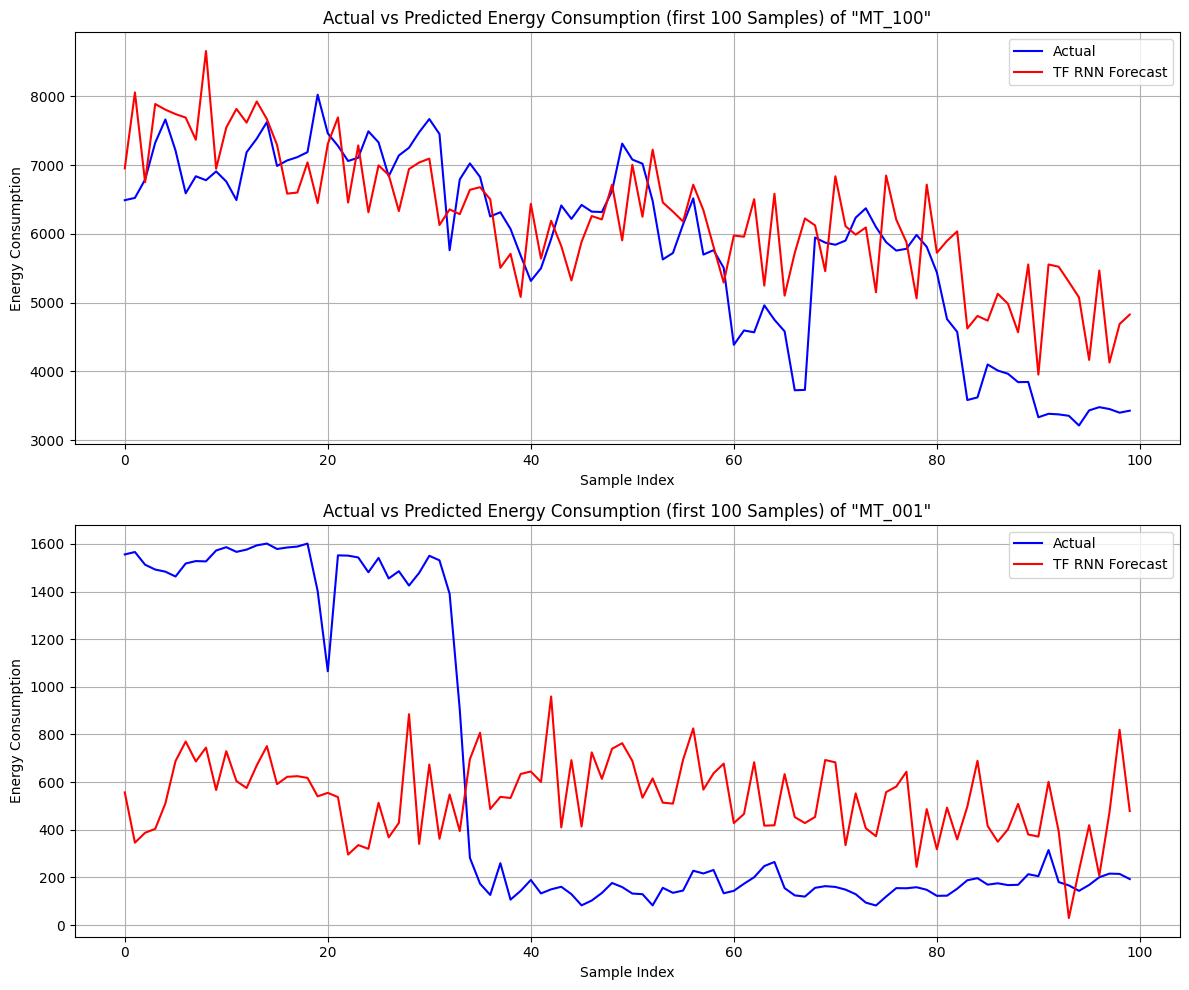

In [ ]:
# Inverse transform the predictions and actuals and Calculate MAE

y_pred_ex_reshaped = scaler_ex.inverse_transform(y_pred_ex)
y_test_ex_unscaled = scaler_ex.inverse_transform(y_test_ex.reshape(-1, y_test_ex.shape[2]))

print(f"Unscaled Mean Squared Error (MAE): {mean_absolute_error(y_test_ex_unscaled, y_pred_ex_reshaped)}")

# Plotting some predictions vs actuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot actual values on first subplot
ax1.plot(y_test_ex_unscaled[:100, -1], label='Actual', color='blue')
ax1.plot(y_pred_ex_reshaped[:100, -1], label='TF RNN Forecast', color='red')
ax1.set_title('Actual vs Predicted Energy Consumption (first 100 Samples) of "MT_100"')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Energy Consumption')
ax1.legend()
ax1.grid(True)

# Plot predictions on second subplot
ax2.plot(y_test_ex_unscaled[:100, 0], label='Actual', color='blue')
ax2.plot(y_pred_ex_reshaped[:100, 0], label='TF RNN Forecast', color='red')
ax2.set_title('Actual vs Predicted Energy Consumption (first 100 Samples) of "MT_001"')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Energy Consumption')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 3. Training RNN Models with Darts

Now we'll explore the Darts library, which offers specialized time series functionality and simplifies the implementation of advanced forecasting models.

In [5]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values

In [6]:
def preprocessing_data_with_DARTS(df,
                      resample_freq='h', agg_method='mean',
                      missing_strategy='linear', 
                      scaling_method='standard',
                      train_ratio=0.7, val_ratio=0.15):
    """
    Complete time series preprocessing pipeline using Darts library.
        
    Returns: train, train_y, val, val_y, test, test_y, scaler
    """
    
    
    # Create Darts TimeSeries
    original_series = TimeSeries.from_dataframe(df)

    # 1. Handle missing values
    filled_series = fill_missing_values(original_series, method=missing_strategy)

    # 2. Resample data
    resampled_series = filled_series.resample(resample_freq, method=agg_method)
    
    # 3. Time-aware split
    
    # Calculate split points
    total_len = len(resampled_series)
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))
    
    # Split the series
    train_series = resampled_series[:train_end]
    val_series = resampled_series[train_end:val_end]
    test_series = resampled_series[val_end:]

    # 4. Scaling (fit only on training data)
    if scaling_method == 'standard':
        scaler = StandardScaler()
    elif scaling_method == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_method == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Unsupported scaling method: {scaling_method}")
        
    scaler = Scaler(scaler)
    
    # Fit on training data and transform all sets
    scaler.fit(train_series)
    train_scaled = scaler.transform(train_series)
    val_scaled = scaler.transform(val_series)
    test_scaled = scaler.transform(test_series)
    
    # 5. WINDOWING
    ######## NOT NEEDED WITH DARTS MODELS ##########

    return train_scaled, val_scaled, test_scaled, scaler

In [7]:
# Preprocess the data (hint: the deep leaning models are data hungry -> keep the sample frequency high (hourly))
train_series_ex, val_series_ex, test_series_ex, scaler_darts_ex = preprocessing_data_with_DARTS(df_excercise,
                                                            resample_freq='h',
                                                            agg_method='sum',
                                                            missing_strategy='linear',
                                                            scaling_method='standard',
                                                            train_ratio=0.7,
                                                            val_ratio=0.15)


In [8]:
print(f"Train: {len(train_series_ex)} samples ({train_series_ex.start_time()} to {train_series_ex.end_time()})")
print(f"Val:   {len(val_series_ex)} samples ({val_series_ex.start_time()} to {val_series_ex.end_time()})")
print(f"Test:  {len(test_series_ex)} samples ({test_series_ex.start_time()} to {test_series_ex.end_time()})")

Train: 18413 samples (2012-01-01 00:00:00 to 2014-02-06 04:00:00)
Val:   3946 samples (2014-02-06 05:00:00 to 2014-07-20 14:00:00)
Test:  3946 samples (2014-07-20 15:00:00 to 2015-01-01 00:00:00)


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train RNN with DARTS</h2>

Explore the Darts library:
1. redesign the RNN model using DARTS lib
2. try out different hypermarameters   
   - Test different window sizes (e.g., 12, 24, 48)
   - Test different hidden layer dimensions (e.g. 100, 150)
   - Adjust the training parameters (e.g., epochs=10,20 ; batchsize=64, 128)

This exercise will help you optimize your model training process to achieve better forecasting results.
</div>

### 3.1 Building the Darts RNN Model

Darts provides a high-level API for time series forecasting models, including various RNN architectures.

In [9]:
from darts.models import BlockRNNModel

#### Darts RNN Model Architecture:
- BlockRNNModel with vanilla RNN cells
- 2 stacked RNN layers with 50 hidden units each
- Adam optimizer with batch size of 256+

**Example Implementation:**

```python
from darts.models import BlockRNNModel

model_darts_ex = BlockRNNModel(
    model="RNN",                        # Use vanilla RNN cells
    input_chunk_length=window_size,     # 24 timesteps lookback
    output_chunk_length=forecast_horizon, # 1 timestep forecast
    hidden_dim=50,                      # 50 hidden units per layer
    n_rnn_layers=2,                     # 2 stacked RNN layers
    batch_size=256,                     # Batch size for training
    activation="adam",                  # Adam optimizer learning rate
    pl_trainer_kwargs={"accelerator": "cpu", "max_epochs": 50},
    random_state=42,
)
```
**What’s happening**:

- `model="RNN"`: Uses a vanilla Recurrent Neural Network cell (no gates like in LSTM or GRU).
- ``input_chunk_length: Number of past time steps the model uses as input. Defines the size of the “look-back window.
- `output_chunk_length`: Number of future time steps the model predicts at once. 

    💡 For "RNN" it is always set to one
- `hidden_dim`: Size of the hidden state vector i.e., how many features represent memory at each step.

    💡 Larger values → more capacity to learn complex temporal patterns.
- `n_rnn_layers`: Number of stacked RNN layers (depth of the recurrent network). The first layer extracts short-term patterns; the second learns higher-level temporal features.
- `batch_size`: Number of training sequences processed together before each gradient update.

    💡 Larger batches improve training speed but need more memory.
- `activation`: Activation function 

    💡 The Adam optimizer — an adaptive learning-rate method that works well for time series.

In [10]:
# Build your own Darts RNN model

window_size = ...
forecast_horizon = 1

# model_darts_ex = BlockRNNModel(
#    ...


In [ ]:
window_size = 24*2
forecast_horizon = 1

model_darts_ex = BlockRNNModel(
    model="RNN",
    input_chunk_length=window_size,
    output_chunk_length=forecast_horizon,
    hidden_dim=100,
    n_rnn_layers=2,
    batch_size=64,
    activation="adam",
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)

### 3.2 Model Training

Let's train our Darts RNN model on the preprocessed time series data.

#### Darts Library
You can easily train (`fit()`) and evaluate (`historical_forecast()`) on test data

**Example Implementation:**

```python
model.fit(
    series=train_data,
    val_series=val_data,
    epochs=num_epochs 
)

model.historical_forecasts(
    series=test_data, 
    forecast_horizon=forecast_horizon, 
    retrain=False, 
    last_points_only=True)
```

Think of `historical_forecasts()` as sliding-window prediction over your past data. Darts runs your model as if it were forecasting in real time, at multiple points in history.

It doesn’t just run `predict()` once. It moves along your `test_series` step by step, predicting ahead at multiple points.

`retrain`: This controls whether the model retrains at each step.

`last_points_only=True`: only return the last predicted point of each forecast window

In [14]:
# Fit your model (think of increasing the epochs for better results)

model_darts_ex.fit(
    series=train_series_ex,         
    val_series=val_series_ex,        
    epochs=20,
    verbose=True
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 40.4 K | train
6 | fc              | Sequential       | 10.1 K | train
-------------------------------------------------------------
50.5 K    Trainable params
0         Non-trainable params
50.5 K    Total params
0.202     Total estimated mo

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 19: 100%|██████████| 287/287 [00:04<00:00, 62.53it/s, train_loss=0.0878, val_loss=0.123]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 287/287 [00:04<00:00, 62.52it/s, train_loss=0.0878, val_loss=0.123]


BlockRNNModel(output_chunk_shift=0, model=RNN, hidden_dim=100, n_rnn_layers=2, hidden_fc_sizes=None, dropout=0.0, activation=adam, use_static_covariates=True, input_chunk_length=48, output_chunk_length=1, batch_size=64, pl_trainer_kwargs={'accelerator': 'cpu'})

### 3.3 Making Predictions

Now we'll generate forecasts using our trained Darts model.

In [15]:
# Make predictions on the test set (use the historical_forecasts method)

pred_series_ex = model_darts_ex.historical_forecasts(series=test_series_ex, forecast_horizon=forecast_horizon, retrain=False, last_points_only=True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### 3.4 Model Evaluation

Let's evaluate our Darts RNN model and compare its performance with the TensorFlow implementation.

Darts RNN MSE: 26009.674335029176


<Axes: title={'center': 'Actual vs Predicted Energy Consumption (last 100 Samples: Household MT_100'}, xlabel='timestamp'>

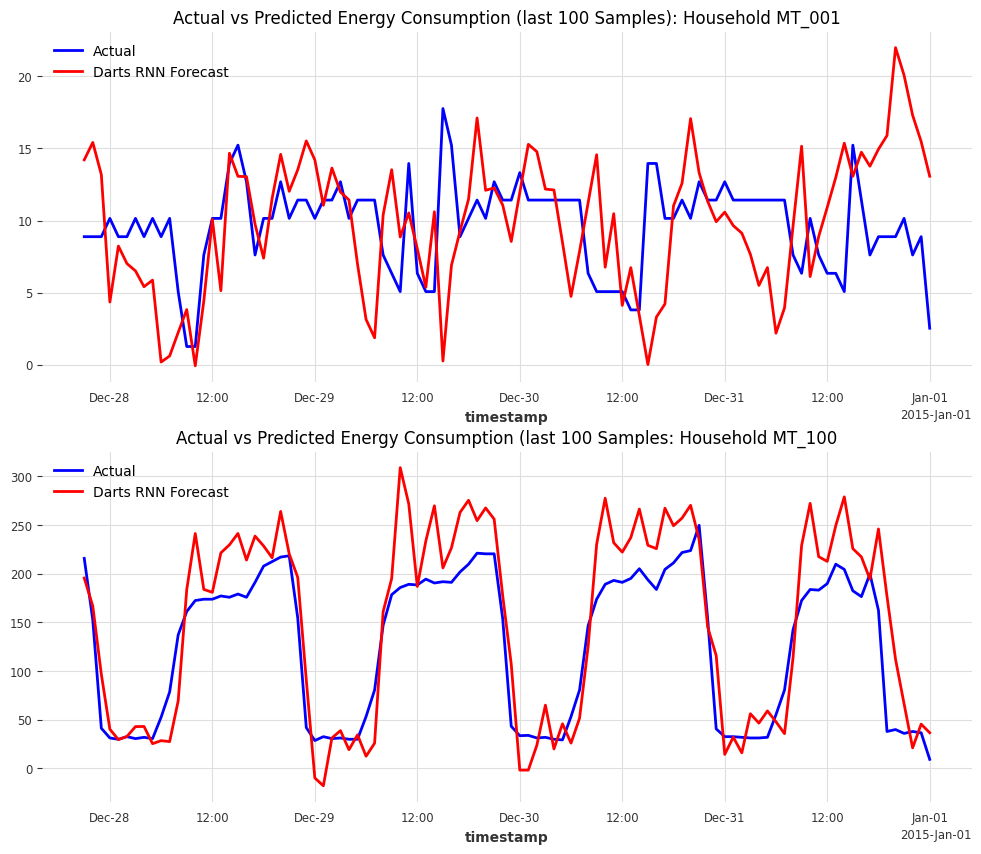

In [ ]:
from darts.metrics import mae

# Inverse transform the predictions and actuals
pred_series_ex_unscaled = scaler_darts_ex.inverse_transform(pred_series_ex)
test_series_ex_unscaled = scaler_darts_ex.inverse_transform(test_series_ex)

# Calculate MAE
print("Darts RNN MAE:", mae(test_series_ex_unscaled, pred_series_ex_unscaled))

# Plotting some predictions vs actuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot actual values on first subplot
test_series_ex_unscaled["MT_001"][-100:].plot(label="Actual", color='blue', ax=ax1)
pred_series_ex_unscaled["MT_001"][-100:].plot(label="Darts RNN Forecast", color='red', title= "Actual vs Predicted Energy Consumption (last 100 Samples): Household MT_001", ax=ax1)

# Plot predictions on second subplot
test_series_ex_unscaled["MT_100"][-100:].plot(label="Actual", color='blue', ax=ax2)
pred_series_ex_unscaled["MT_100"][-100:].plot(label="Darts RNN Forecast", color='red', title= "Actual vs Predicted Energy Consumption (last 100 Samples: Household MT_100", ax=ax2)

## ✅ Summary

## What You've Accomplished:
- Built and trained RNN models using TensorFlow/Keras
- Learned the Darts library for specialized time series forecasting
- Implemented preprocessing pipelines for both TensorFlow and Darts workflows
- Applied RNN techniques to energy consumption datasets
- Compared performance between TensorFlow and Darts implementations

These skills provide a foundation for building production-ready time series forecasting systems.